In [436]:
#!pip install pandas numpy scikit-learn matplotlib openpyxl

In [437]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online Retail.xlsx")
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (541909, 8)

Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

First rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country

In [438]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Task 1: Data Profiling and Missing Values (~25 minutes)


## 1.1 — Profile the raw data
- Compute a comprehensive profile of the dataset:

- Number of rows, columns, and memory usage
- Missing value counts and percentages for each column
- Number of unique values per column
- Basic statistics for numeric columns (min, max, mean, median, std)

In [439]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [440]:
num_col = len(df.columns)
num_col

8

In [441]:
num_row = len(df)
num_row

541909

In [442]:
import os 
f" {os.path.getsize("Online Retail.xlsx")/(1024*1024)} MB"

' 22.616714477539062 MB'

In [443]:
missing_percentage = (df.isna().sum()/len(df))*100
print(missing_percentage)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [444]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [445]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


## 1.2 — Classify the missing data types
- The two columns with significant missing values are CustomerID and Description.

For each:

- Determine whether the missingness is MNAR, MAR, or MCAR. Justify your answer with evidence (e.g., compare rows with and without missing values — do they differ systematically in other columns?).
- Decide on a strategy: deletion, imputation, or indicator column. Justify your choice.

Guiding questions:

- Are transactions with missing CustomerID different from those with a CustomerID? Check the distribution of Country, Quantity, and UnitPrice for both groups.
- Do transactions with missing Description have valid StockCode values? Could you recover descriptions from other rows with the same StockCode?

In [446]:
missing_customer = df[df["CustomerID"].isna()]
non_missing_customer = df[df["CustomerID"].notna()]

In [447]:
print(missing_customer["Country"].value_counts(normalize=True).head(10))
print(non_missing_customer["Country"].value_counts(normalize=True).head(10))

Country
United Kingdom    0.989044
EIRE              0.005264
Hong Kong         0.002132
Unspecified       0.001495
Switzerland       0.000925
France            0.000489
Israel            0.000348
Portugal          0.000289
Bahrain           0.000015
Name: proportion, dtype: float64
Country
United Kingdom    0.889509
Germany           0.023339
France            0.020871
EIRE              0.018398
Spain             0.006226
Netherlands       0.005828
Belgium           0.005086
Switzerland       0.004614
Portugal          0.003638
Australia         0.003095
Name: proportion, dtype: float64


In [448]:
print(missing_customer["Quantity"].describe())
print(non_missing_customer["Quantity"].describe())

count    135080.000000
mean          1.995573
std          66.696153
min       -9600.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        5568.000000
Name: Quantity, dtype: float64
count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64


In [449]:
print(missing_customer["UnitPrice"].describe())
print(non_missing_customer["UnitPrice"].describe())

count    135080.000000
mean          8.076577
std         151.900816
min      -11062.060000
25%           1.630000
50%           3.290000
75%           5.450000
max       17836.460000
Name: UnitPrice, dtype: float64
count    406829.000000
mean          3.460471
std          69.315162
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64


CustomerID Missingness Analysis

To better understand the missingness of CustomerID, we compared transactions with and without a customer identifier across several variables, including Country, Quantity, and UnitPrice.

The analysis shows systematic differences between the two groups:

Transactions with missing CustomerID are overwhelmingly from the United Kingdom (~99%)

These transactions also tend to have smaller order quantities

They also show different price distributions

For example, the median UnitPrice for transactions with missing CustomerID is 3.29, compared to 1.95 for transactions with a valid CustomerID.

These differences indicate that the missingness is not completely random and is associated with other observed variables in the dataset.

Therefore, the missingness mechanism is best classified as MAR (Missing At Random).

Strategy

Since CustomerID cannot be reliably imputed and is required for customer-level analysis, rows with missing CustomerID will be removed from the dataset.

In [450]:
df[df["Description"].isna()][["StockCode","Description"]].head(10)

,StockCode,Description
622,22139,NaN
1970,21134,NaN
1971,22145,NaN
1972,37509,NaN
1987,85226A,NaN
1988,85044,NaN
2024,20950,NaN
2025,37461,NaN
2026,84670,NaN
2406,21777,NaN


In [451]:
df[df["StockCode"] == 21777]["Description"].unique()

array(['RECIPE BOX WITH METAL HEART', nan], dtype=object)

In [452]:
df1 = df.copy()

description_map = df1.groupby("StockCode")["Description"].first()

df1["Description"] = df1["Description"].fillna(
    df1["StockCode"].map(description_map)
)

In [453]:
df1['Description'].isna().sum()

np.int64(112)

In [454]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541797 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [455]:
df1[df1['StockCode']== 21777]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
19,536367,21777,RECIPE BOX WITH METAL HEART,4,2010-12-01 08:34:00,7.95,13047.0,United Kingdom
2140,536562,21777,RECIPE BOX WITH METAL HEART,2,2010-12-01 15:08:00,7.95,13468.0,United Kingdom
2399,536588,21777,RECIPE BOX WITH METAL HEART,1,2010-12-01 16:49:00,7.95,17069.0,United Kingdom
2406,536589,21777,RECIPE BOX WITH METAL HEART,-10,2010-12-01 16:50:00,0.00,NaN,United Kingdom
2587,536592,21777,RECIPE BOX WITH METAL HEART,2,2010-12-01 17:06:00,7.95,NaN,United Kingdom
10350,537237,21777,RECIPE BOX WITH METAL HEART,1,2010-12-06 09:58:00,7.95,NaN,United Kingdom
11104,537240,21777,RECIPE BOX WITH METAL HEART,2,2010-12-06 10:08:00,7.95,NaN,United Kingdom
12008,537361,21777,RECIPE BOX WITH METAL HEART,5,2010-12-06 12:34:00,0.00,NaN,United Kingdom
21702,C538112,21777,RECIPE BOX WITH METAL HEART,-3,2010-12-09 15:28:00,7.95,14898.0,United Kingdom
21750,C538119,21777,RECIPE BOX WITH METAL HEART,-2,2010-12-09 15:34:00,7.95,13136.0,United Kingdom


Description Missingness Analysis

Transactions with missing Description values still contain valid StockCode values. Since each StockCode corresponds to a specific product, the product description can often be found in other rows with the same StockCode.

By checking other transactions with identical StockCode values, we observe that the correct product description exists elsewhere in the dataset. Therefore, the missing descriptions can be recovered from these rows.

This indicates that the missingness is MAR (Missing At Random), because the missing values can be inferred from other observed variables in the dataset.

Strategy

Missing descriptions will be imputed using the description associated with the same StockCode.

In [456]:
df1['StockCode'].nunique()

4070

In [457]:
df1[df1['CustomerID'].isna() & df1['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
280754,561498,21610,NaN,-14,2011-07-27 14:10:00,0.0,NaN,United Kingdom
281615,561555,37477B,NaN,-11,2011-07-28 10:21:00,0.0,NaN,United Kingdom
281616,561557,37477C,NaN,-31,2011-07-28 10:21:00,0.0,NaN,United Kingdom
346849,567207,35592T,NaN,4,2011-09-19 11:01:00,0.0,NaN,United Kingdom


## 1.3 — Handle the missing values
- Apply your chosen strategies. Document what you did and why. After handling missing values, print the remaining missing value counts to confirm.

In [458]:
df1 = df1.dropna(subset=["CustomerID"])
df1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [459]:
df1.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# Task 2: Cleaning Invalid and Anomalous Records (~25 minutes)


## 2.1 — Identify cancellations

Invoices starting with "C" are cancellations. These have negative quantities and represent returns, not purchases.

- Count how many cancellation transactions exist.
- Decide whether to keep, remove, or flag them. Think about the downstream task: if you later want to predict customer churn or build a recommender, how do cancellations affect the analysis?

In [460]:
df1["InvoiceNo"].str.startswith("C").sum()

8905

In [461]:
df1 = df1[~df1["InvoiceNo"].astype(str).str.startswith("C")]

In [462]:
df1["InvoiceNo"] = df1["InvoiceNo"].astype(str)

In [463]:
df1.dtypes

InvoiceNo                 str
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [464]:
df1["InvoiceNo"].str.startswith('C').sum()

np.int64(0)

In [465]:
print(df1.shape)

(397924, 8)


In [466]:
df1["Quantity"].min()

np.int64(1)

### Impact on Downstream Analysis

Cancellation transactions represent returned or cancelled purchases, not actual successful sales. These records usually have invoice numbers starting with "C" and often contain negative quantities.

The decision to remove or keep these records depends on the downstream task.

For product recommendation systems, cancellations can introduce misleading signals. If returns are treated as normal purchases, the model may incorrectly assume that a customer liked a product that they actually returned. This can reduce the quality of recommendations. Therefore, removing cancellations helps ensure that the dataset reflects true purchasing behavior.

For customer churn prediction, cancellation behavior may actually be informative. Frequent returns could indicate customer dissatisfaction and may signal a higher likelihood of churn. In this case, cancellations could be kept in the dataset and possibly used as a feature.

In this analysis, cancellation transactions were removed because the focus is on understanding actual purchasing behavior and product demand.

## 2.2 — Handle invalid quantities and prices

Investigate records with:
- `Quantity <= 0` (that are not cancellations)
- `UnitPrice <= 0`
- Extreme outliers in `Quantity` or `UnitPrice`

For each category of invalid record:
- Count how many exist
- Decide what to do (remove, cap, flag) and justify

In [467]:
invalid_quantity = df1[df1["Quantity"] <= 0]

print("Invalid quantity records:", len(invalid_quantity))

Invalid quantity records: 0


In [468]:
invalid_price = df1[df1["UnitPrice"] <= 0]

print("Invalid price records:", len(invalid_price))

Invalid price records: 40


In [469]:
Q1_p = df1["UnitPrice"].quantile(0.25)
Q3_p = df1["UnitPrice"].quantile(0.75)
IQR_p = Q3_p - Q1_p

lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p

price_outliers = df1[(df1["UnitPrice"] < lower_p) | (df1["UnitPrice"] > upper_p)]

print("Extreme price outliers:", len(price_outliers))

Extreme price outliers: 34356


In [470]:
Q1_q = df1["Quantity"].quantile(0.25)
Q3_q = df1["Quantity"].quantile(0.75)
IQR_q = Q3_q - Q1_q

lower_q = Q1_q - 1.5 * IQR_q
upper_q = Q3_q + 1.5 * IQR_q

quantity_outliers = df1[(df1["Quantity"] < lower_q) | (df1["Quantity"] > upper_q)]

print("Extreme Quantity outliers:", len(quantity_outliers))

Extreme Quantity outliers: 25656


### Handling Invalid Quantities and Prices

The dataset was examined for two categories of potentially invalid records:
(1) Quantity ≤ 0, (2) UnitPrice ≤ 0

Quantity ≤ 0 (not cancellations)

After removing cancellation transactions earlier (invoices starting with "C"), we checked for remaining transactions with non-positive quantities.

Count: 0 records

Since cancellation records were already removed and no additional transactions with Quantity ≤ 0 remained, no further action was required for this category.

UnitPrice ≤ 0

Transactions with non-positive prices were identified.

Count: 40 records

A unit price of zero or negative does not represent a valid sale and may correspond to data entry errors, promotional giveaways, or free samples. Because the goal of the analysis is to study actual purchasing behavior and revenue patterns, these transactions would distort revenue calculations.

Decision: These records were removed from the dataset.

## 2.3 — Clean and validate
Apply your cleaning rules. After cleaning, verify:

- No remaining negative quantities (unless you kept cancellations with a flag)
- No zero or negative prices
- Print the shape before and after cleaning

In [471]:
df2 = df1.copy()
df2 = df2[df2["UnitPrice"] > 0]

In [472]:
len(df1[df1['Quantity'] <= 0])

0

In [473]:
len(df2[df2['UnitPrice'] <= 0])

0

In [474]:
print(df1.shape)
print(df2.shape)

(397924, 8)
(397884, 8)


# Task 3: Categorical Data Challenges (~20 minutes)


## 3.1 — Analyze the Country column

- How many unique countries are there?
- What percentage of transactions come from the top 5 countries?
- How many countries have fewer than 50 transactions?

Create a cleaned version of the `Country` column that groups rare countries (fewer than 50 transactions) into an "Other" category. Compare the number of categories before and after.

In [475]:
df2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [476]:
df2['Country'].nunique()

37

In [477]:
((df2.groupby('Country')['InvoiceNo'].count().sort_values(ascending= False).head(5)).sum() / len(df2))*100

np.float64(95.86261322395472)

In [478]:
fewer_transactions = df2.groupby('Country')['InvoiceNo'].count()
len(fewer_transactions[fewer_transactions<50])

6

In [479]:
country_counts = df2['Country'].value_counts()

rare_countries = country_counts[country_counts < 50].index

df2['Country_clean'] = df2['Country'].replace(rare_countries, "Other")

In [480]:
df2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,France


In [481]:
print("Number of categories before grouping:" ,df2['Country'].nunique())
print("Number of categories after grouping:" ,df2['Country_clean'].nunique())


Number of categories before grouping: 37
Number of categories after grouping: 32


## 3.2 — Analyze the StockCode column

`StockCode` is a high-cardinality categorical feature.

- How many unique stock codes exist?
- Are there non-product codes (e.g., postage, discounts, manual adjustments)? Identify them by looking at codes that are not purely numeric or have unusual patterns.
- Decide how to handle non-product codes for a product-level analysis.


In [482]:
df2

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,France


In [483]:
df2['StockCode'].nunique()

3665

In [484]:
df2[pd.to_numeric(df2['StockCode'], errors = 'coerce').isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.00,12583.0,France,France
...,...,...,...,...,...,...,...,...,...
541778,581578,84997C,CHILDRENS CUTLERY POLKADOT BLUE,8,2011-12-09 12:16:00,4.15,12713.0,Germany,Germany
541809,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom,United Kingdom
541838,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom,United Kingdom
541844,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom,United Kingdom


In [485]:
df3 = df2.copy()
df3 = df3[pd.to_numeric(df2['StockCode'], errors='coerce').notna()]
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,France


### Analysis of the StockCode Column

The `StockCode` column represents product identifiers and contains **3665 unique values**, indicating a high-cardinality categorical feature.

To identify potential non-product codes, we checked for values that are **not purely numeric**. This revealed several codes such as **"POST"** and **"M"**, which correspond to postage fees and manual adjustments rather than actual products.

These codes represent operational or financial adjustments rather than physical products.

**Decision**

Since the goal of the analysis is to focus on **product-level behavior**, these non-product codes were removed from the dataset to ensure that only actual products are included in the analysis.

## 3.3 — Engineer a feature from Description

The `Description` column contains free text. Create a simple feature from it — for example, the word count of the description, or a flag for descriptions containing certain keywords (e.g., "SET", "PACK", "VINTAGE"). Show that your engineered feature has a meaningful relationship with `Quantity` or `UnitPrice`.

In [486]:
df3['is_PACK'] = df3['Description'].str.contains("PACK", case=False, na=False)
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean,is_PACK
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom,False
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,France,True
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,France,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,France,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,France,False


In [487]:
df3.groupby("is_PACK")[["Quantity","UnitPrice"]].mean()

,Quantity,UnitPrice
is_PACK,,
False,12.796177,2.956478
True,21.421953,0.912027


### Feature Engineering from Description

A binary feature called **is_PACK** was created to indicate whether the product description contains the word **"PACK"**.

Products labeled as packs usually contain multiple items bundled together and are often sold at lower prices per unit.

To evaluate whether this feature captures meaningful information, we compared the average **Quantity** and **UnitPrice** between products that contain the keyword **PACK** and those that do not.

The results show that products labeled as **PACK** tend to have:

- **Higher average quantities purchased** (≈21.4 vs ≈12.8)
- **Lower average unit prices** (≈0.91 vs ≈2.96)

This suggests that pack-based products are typically cheaper per unit and purchased in larger quantities. Therefore, the engineered feature captures meaningful differences in purchasing behavior.

# Task 4: Class Imbalance — Predicting High-Value Customers (~25 minutes)


## 4.1 — Engineer a binary target

Create a customer-level dataset by aggregating transactions per `CustomerID`. Compute:
- Total revenue (`Quantity * UnitPrice`)
- Number of orders (unique `InvoiceNo` values)
- Number of distinct products purchased
- Date of first and last purchase

Define a binary target: a customer is **high-value** if their total revenue is in the top 10%. Label these as `1` and the rest as `0`.

```python
# Hint: compute total revenue per customer, then use a percentile threshold
customer_revenue = df.groupby("CustomerID").apply(
    lambda x: (x["Quantity"] * x["UnitPrice"]).sum()
).reset_index(name="total_revenue")
```


In [488]:
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Country_clean,is_PACK
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,United Kingdom,False
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,France,True
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,France,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,France,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,France,False


In [489]:
customer_revenue = df3.groupby("CustomerID").apply(
    lambda x: (x["Quantity"] * x["UnitPrice"]).sum()
).reset_index(name="total_revenue")
customer_revenue

,CustomerID,total_revenue
0,12346.0,77183.60
1,12347.0,3653.45
2,12348.0,1437.24
3,12349.0,1372.42
4,12350.0,258.00
...,...,...
4309,18280.0,180.60
4310,18281.0,80.82
4311,18282.0,178.05
4312,18283.0,1964.26


In [490]:
orders = df3.groupby("CustomerID")["InvoiceNo"].nunique().reset_index(name="num_orders")
orders

,CustomerID,num_orders
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4309,18280.0,1
4310,18281.0,1
4311,18282.0,2
4312,18283.0,16


In [491]:
products = df3.groupby("CustomerID")["StockCode"].nunique().reset_index(name="num_products")
products

,CustomerID,num_products
0,12346.0,1
1,12347.0,90
2,12348.0,21
3,12349.0,68
4,12350.0,13
...,...,...
4309,18280.0,10
4310,18281.0,7
4311,18282.0,12
4312,18283.0,252


In [492]:
dates = df3.groupby("CustomerID")["InvoiceDate"].agg(
    first_purchase="min",
    last_purchase="max"
).reset_index()
dates

,CustomerID,first_purchase,last_purchase
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00
...,...,...,...
4309,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00
4310,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00
4311,18282.0,2011-08-05 13:35:00,2011-12-02 11:43:00
4312,18283.0,2011-01-06 14:14:00,2011-12-06 12:02:00


In [493]:
threshold = customer_revenue["total_revenue"].quantile(0.9)
threshold

np.float64(3265.15)

In [494]:
customer_revenue["high_value"] = (customer_revenue["total_revenue"] >= threshold).astype(int)
customer_revenue

,CustomerID,total_revenue,high_value
0,12346.0,77183.60,1
1,12347.0,3653.45,1
2,12348.0,1437.24,0
3,12349.0,1372.42,0
4,12350.0,258.00,0
...,...,...,...
4309,18280.0,180.60,0
4310,18281.0,80.82,0
4311,18282.0,178.05,0
4312,18283.0,1964.26,0


In [495]:
customer_df = customer_revenue.merge(orders, on="CustomerID")
customer_df = customer_df.merge(products, on="CustomerID")
customer_df = customer_df.merge(dates, on="CustomerID")
customer_df

,CustomerID,total_revenue,high_value,num_orders,num_products,first_purchase,last_purchase
0,12346.0,77183.60,1,1,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,3653.45,1,7,90,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,1437.24,0,4,21,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1372.42,0,1,68,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,258.00,0,1,13,2011-02-02 16:01:00,2011-02-02 16:01:00
...,...,...,...,...,...,...,...
4309,18280.0,180.60,0,1,10,2011-03-07 09:52:00,2011-03-07 09:52:00
4310,18281.0,80.82,0,1,7,2011-06-12 10:53:00,2011-06-12 10:53:00
4311,18282.0,178.05,0,2,12,2011-08-05 13:35:00,2011-12-02 11:43:00
4312,18283.0,1964.26,0,16,252,2011-01-06 14:14:00,2011-12-06 12:02:00


## 4.2 — Measure the imbalance

- What is the class distribution (high-value vs. regular)?
- If a model always predicted "regular," what would its accuracy be?
- Why is accuracy a poor metric here?

In [496]:
customer_df['high_value'].value_counts(normalize=True)*100

high_value
0    89.986092
1    10.013908
Name: proportion, dtype: float64

<Axes: xlabel='high_value'>

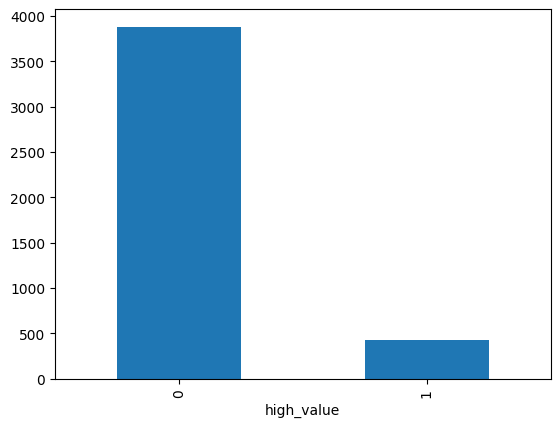

In [497]:
(customer_df['high_value'].value_counts()).plot(kind='bar')

### Class Imbalance Analysis

The dataset is highly imbalanced.

- Regular customers (0): ~90%
- High-value customers (1): ~10%

If a model always predicted **"regular"**, it would achieve approximately **90% accuracy**, because the majority of customers belong to the regular class.

However, this model would fail to identify **high-value customers**, which are the most important segment for business analysis.

Therefore, **accuracy is a poor evaluation metric** in this case. Metrics such as **precision, recall, F1-score, or ROC-AUC** are more appropriate for evaluating models on imbalanced datasets.

## 4.3 — Apply resampling

Split the customer-level dataset into train and test sets (80/20). Then apply two resampling techniques to the **training set only**:

1. **Random oversampling** of the minority class
2. **Random undersampling** of the majority class

For each:
- Print the class distribution before and after resampling
- Train a simple model (e.g., `LogisticRegression` or `DecisionTreeClassifier`) on both the original and resampled training sets
- Evaluate on the **original (not resampled) test set** using precision, recall, and F1 for the high-value class


In [498]:
customer_df

,CustomerID,total_revenue,high_value,num_orders,num_products,first_purchase,last_purchase
0,12346.0,77183.60,1,1,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,3653.45,1,7,90,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348.0,1437.24,0,4,21,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349.0,1372.42,0,1,68,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,258.00,0,1,13,2011-02-02 16:01:00,2011-02-02 16:01:00
...,...,...,...,...,...,...,...
4309,18280.0,180.60,0,1,10,2011-03-07 09:52:00,2011-03-07 09:52:00
4310,18281.0,80.82,0,1,7,2011-06-12 10:53:00,2011-06-12 10:53:00
4311,18282.0,178.05,0,2,12,2011-08-05 13:35:00,2011-12-02 11:43:00
4312,18283.0,1964.26,0,16,252,2011-01-06 14:14:00,2011-12-06 12:02:00


In [499]:
X = customer_df[["num_orders", "num_products"]]

y = customer_df["high_value"]

In [500]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [501]:
print("Before resampling:")
print(y_train.value_counts())

Before resampling:
high_value
0    3105
1     346
Name: count, dtype: int64


In [502]:
from sklearn.utils import resample

train_data = X_train.copy()
train_data["target"] = y_train

majority = train_data[train_data["target"] == 0]
minority = train_data[train_data["target"] == 1]

minority_oversampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

oversampled = pd.concat([majority, minority_oversampled])

In [503]:
oversampled

,num_orders,num_products,target
3277,1,7,0
1389,1,7,0
1641,5,204,0
1480,1,4,0
475,1,104,0
...,...,...,...
1347,25,95,1
3055,26,67,1
2344,14,367,1
3158,20,22,1


In [504]:
print("After oversampling:")
print(oversampled["target"].value_counts())

After oversampling:
target
0    3105
1    3105
Name: count, dtype: int64


In [505]:
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

undersampled = pd.concat([majority_downsampled, minority])

In [506]:
print("After undersampling:")
print(undersampled["target"].value_counts())

After undersampling:
target
0    346
1    346
Name: count, dtype: int64


In [507]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [508]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Original training:")
print(classification_report(y_test, pred))

Original training:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       777
           1       0.75      0.49      0.59        86

    accuracy                           0.93       863
   macro avg       0.85      0.74      0.78       863
weighted avg       0.93      0.93      0.93       863



In [509]:
X_over = oversampled.drop("target", axis=1)
y_over = oversampled["target"]

model.fit(X_over, y_over)

pred_over = model.predict(X_test)

print("Oversampled training:")
print(classification_report(y_test, pred_over))

Oversampled training:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       777
           1       0.45      0.83      0.58        86

    accuracy                           0.88       863
   macro avg       0.71      0.86      0.76       863
weighted avg       0.93      0.88      0.90       863



In [510]:
X_under = undersampled.drop("target", axis=1)
y_under = undersampled["target"]

model.fit(X_under, y_under)

pred_under = model.predict(X_test)

print("Undersampled training:")
print(classification_report(y_test, pred_under))

Undersampled training:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       777
           1       0.44      0.83      0.58        86

    accuracy                           0.88       863
   macro avg       0.71      0.86      0.75       863
weighted avg       0.93      0.88      0.89       863



### Resampling for Class Imbalance

The dataset is highly imbalanced, with only about 10% of customers labeled as high-value.

To address this, two resampling techniques were applied to the training data:

- **Random Oversampling:** The minority class (high-value customers) was duplicated until both classes were balanced.
- **Random Undersampling:** The majority class (regular customers) was randomly reduced to match the minority class size.

Models were trained on:
1. The original training data
2. The oversampled training data
3. The undersampled training data

All models were evaluated on the **original test set** using precision, recall, and F1-score for the high-value class.

## 4.4 — Compare results

Create a summary table comparing:

| Method | Precision | Recall | F1 |
|---|---|---|---|
| No resampling | | | |
| Oversampling | | | |
| Undersampling | | | |

Which method best balances precision and recall for the high-value class? Write 3-5 sentences explaining your findings.


### Comparison of Resampling Methods

The table below compares the three modeling approaches for the **high-value customer class (1)**.

| Method | Precision | Recall | F1 |
|---|---:|---:|---:|
| No resampling | 0.75 | 0.49 | 0.59 |
| Oversampling | 0.45 | 0.83 | 0.58 |
| Undersampling | 0.44 | 0.83 | 0.58 |

The results show a clear trade-off between **precision** and **recall**. Without resampling, the model achieves the highest precision (0.75), meaning that most customers predicted as high-value are actually high-value. However, its recall is much lower (0.49), so it misses many real high-value customers.

Both oversampling and undersampling substantially improve recall to 0.83, which means the model captures most of the true high-value customers. However, this comes at the cost of much lower precision, since many regular customers are incorrectly labeled as high-value. In this case, **no resampling gives the highest F1-score (0.59)**, so it provides the best overall balance between precision and recall, although the difference from the resampled methods is small.

# Task 5: Data Leakage — Introduce, Detect, and Fix (~25 minutes)


## 5.1 — Intentionally introduce temporal leakage

The dataset spans December 2010 through December 2011. Suppose you want to predict whether a customer will make a purchase in December 2011 based on their behavior in earlier months.

First, do it **wrong**: randomly split all customer features (computed from the full date range) into train and test sets. Train a model and record its performance.


In [511]:
X = customer_df[["num_orders", "num_products"]]
y = customer_df["high_value"]

In [512]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [513]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       767
           1       0.81      0.45      0.58        96

    accuracy                           0.93       863
   macro avg       0.87      0.72      0.77       863
weighted avg       0.92      0.93      0.92       863



### Temporal Leakage (Incorrect Approach)

First, the dataset was randomly split into training and test sets using features computed from the **entire date range (Dec 2010 – Dec 2011)**.

This approach is incorrect because it allows information from the **future** to leak into the training data. For example, features such as the total number of orders or products purchased may include activity from December 2011, even though the goal is to predict behavior in that month.

As a result, the model may appear to perform better than it would in a real-world scenario, because it has indirectly seen information from the period it is supposed to predict.

## 5.2 — Detect the leakage

- Check whether train and test sets contain features computed from overlapping time periods.
- Look for suspiciously high model performance (a sign of leakage).
- Compute feature-target correlations and identify any that seem too good to be true.

In [514]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [515]:
customer_df[["num_orders","num_products","total_revenue","high_value"]].corr()

,num_orders,num_products,total_revenue,high_value
num_orders,1.000000,0.686681,0.533196,0.534022
num_products,0.686681,1.000000,0.375712,0.472941
total_revenue,0.533196,0.375712,1.000000,0.377033
high_value,0.534022,0.472941,0.377033,1.000000


### Feature–Target Correlation Analysis

To further investigate potential leakage, we examined the correlations between the engineered features and the target variable (`high_value`).

The correlation matrix shows that `num_orders` and `num_products` have moderate positive correlations with the target (0.53 and 0.47 respectively). This indicates that customers who place more orders or purchase more distinct products are more likely to be classified as high-value customers.

The `total_revenue` feature also shows a positive correlation with the target. However, this relationship is expected because the high-value label was originally defined using customer revenue. Including this feature in the model could introduce **data leakage**, since the model would effectively be using information directly related to the target.

These results confirm that certain features may contain information that strongly reflects the target variable, which can lead to overly optimistic model performance if not handled carefully.

## 5.3 — Fix with a correct temporal split

Now do it **right**:
- Use data from December 2010 through September 2011 to compute customer features (the "observation window").
- Use data from October 2011 through December 2011 to create the target variable: did the customer make at least one purchase in this "prediction window"?
- Train the same model and compare performance.

```python
# Temporal split
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

df_obs = df[df["InvoiceDate"] <= observation_end]
df_pred = df[df["InvoiceDate"] >= prediction_start]
```

In [516]:
observation_end = pd.Timestamp("2011-09-30")
prediction_start = pd.Timestamp("2011-10-01")

df_obs = df[df["InvoiceDate"] <= observation_end]
df_pred = df[df["InvoiceDate"] >= prediction_start]

In [517]:
customer_features = df_obs.groupby("CustomerID").agg(
    num_orders=("InvoiceNo", "nunique"),
    num_products=("StockCode", "nunique"),
    total_revenue=("Quantity", lambda x: (x * df_obs.loc[x.index, "UnitPrice"]).sum())
).reset_index()

did the customer purchase in Oct–Dec 2011?

In [518]:
customer_target = df_pred.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

customer_target["target"] = (customer_target["InvoiceNo"] > 0).astype(int)

customer_target = customer_target[["CustomerID", "target"]]
customer_target

,CustomerID,target
0,12347.0,1
1,12349.0,1
2,12352.0,1
3,12356.0,1
4,12357.0,1
...,...,...
2596,18276.0,1
2597,18277.0,1
2598,18282.0,1
2599,18283.0,1


In [519]:
customer_dataset = customer_features.merge(
    customer_target,
    on="CustomerID",
    how="left"
)

customer_dataset["target"] = customer_dataset["target"].fillna(0)
customer_dataset

,CustomerID,num_orders,num_products,total_revenue,target
0,12346.0,2,1,0.00,0.0
1,12347.0,5,82,2790.86,1.0
2,12348.0,4,22,1797.24,0.0
3,12350.0,1,17,334.40,0.0
4,12352.0,10,47,1233.68,1.0
...,...,...,...,...,...
3641,18280.0,1,10,180.60,0.0
3642,18281.0,1,7,80.82,0.0
3643,18282.0,2,7,98.76,1.0
3644,18283.0,10,192,1120.67,1.0


In [520]:
X = customer_dataset[["num_orders", "num_products", "total_revenue"]]
y = customer_dataset["target"]

In [521]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [522]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.63      0.77      0.69       353
         1.0       0.73      0.58      0.64       377

    accuracy                           0.67       730
   macro avg       0.68      0.67      0.67       730
weighted avg       0.68      0.67      0.67       730



### Model Performance with Temporal Split

After applying the correct temporal split, the model performance decreased compared to the previous experiment. This is expected because the model no longer has access to future information.

The model achieved an overall accuracy of **67%**, indicating moderate predictive ability. For customers who made a purchase in the prediction window (class 1), the model achieved a **precision of 0.73** and a **recall of 0.58**, meaning it correctly identifies a reasonable portion of future purchasers.

The drop in performance compared to the earlier experiment suggests that the previous approach likely benefited from **temporal leakage**, where information from the future was inadvertently used in training.

Using a time-based split ensures that the evaluation better reflects how the model would perform in a real-world deployment scenario.

## 5.4 — Compare and reflect

Create a table comparing:

| Split method | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Random (leaked) | | | | |
| Temporal (correct) | | | | |

Write 5-8 sentences explaining:
- Why did the leaked model perform better?
- What specific information leaked?
- Why is the temporal split the correct approach for this task?

In [523]:
import pandas as pd

results = pd.DataFrame({
    "Split method": ["Random (leaked)", "Temporal (correct)"],
    "Accuracy": [0.93, 0.67],
    "Precision": [0.75, 0.73],
    "Recall": [0.49, 0.58],
    "F1": [0.59, 0.64]
})

results

,Split method,Accuracy,Precision,Recall,F1
0,Random (leaked),0.93,0.75,0.49,0.59
1,Temporal (correct),0.67,0.73,0.58,0.64


### Comparison of Random vs Temporal Split

The model trained using a random split achieved significantly higher accuracy (93%) compared to the temporal split model (67%). This occurs because the random split allows information from the future to indirectly appear in both the training and test sets.

In the leaked setup, customer features were computed using data from the entire time range, including the period that the model was supposed to predict. As a result, the model had access to behavioral information that already reflected future purchases.

This type of information leakage artificially improves model performance because the model is effectively learning patterns that include knowledge of the outcome.

In contrast, the temporal split separates the data into an observation window and a prediction window. Features are computed only from the observation period, while the target is defined using future behavior.

This ensures that the model only uses information that would realistically be available at prediction time. Although the performance decreases, the evaluation becomes much more reliable and representative of real-world deployment.